<a href="https://colab.research.google.com/github/mkolennikova/TEB-Ru/blob/main/run_in_collab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Basic imports

In [3]:
import os, sys, shutil, glob, time
import subprocess
import importlib
import pandas as pd
from pathlib import Path

def import_and_reload (module_name: str):
    """Loads a module by name, or reloads it if already imported."""
    if module_name in sys.modules:
        print(f"Reloading existing module: {module_name}")
        return importlib.reload(sys.modules[module_name])
    else:
        print(f"Loading new module: {module_name}")
        return importlib.import_module(module_name)


In [5]:
opts = {'use_gdrive': False,
        'reload_repo': True,
        'repo_path': 'https://github.com/mkolennikova/TEB-Ru'}

MODEL_NAME = os.path.basename(os.path.normpath(opts['repo_path']))

In [6]:
if opts['use_gdrive']:
  from google.colab import drive
  drive.mount('/content/drive')
  WORK_DIR = '/content/drive/MyDrive/TEB_work'
else:
  WORK_DIR = '/content/TEB_work'

MODEL_DIR = WORK_DIR + '/' + MODEL_NAME

os.makedirs(WORK_DIR, exist_ok = True)


## Update model from GitHub (clone or pull)

In [7]:
os.chdir (WORK_DIR)
if not os.path.isdir (MODEL_NAME) or opts['reload_repo']:
  if os.path.isdir (MODEL_NAME):
    %rm -r {MODEL_NAME}
  !git clone {opts['repo_path']}
else:
  os.chdir(MODEL_DIR)
  !git pull



Cloning into 'TEB-Ru'...
remote: Enumerating objects: 357, done.
remote: Counting objects: 100% (357/357), done.
remote: Compressing objects: 100% (245/245), done.
remote: Total 357 (delta 154), reused 304 (delta 108), pack-reused 0 (from 0)
Receiving objects: 100% (357/357), 2.60 MiB | 11.54 MiB/s, done.
Resolving deltas: 100% (154/154), done.


In [8]:
sys.path.append (MODEL_DIR + '/python/')
install_utils = import_and_reload ('install_utils')

install_utils.import_extrernal_modules()


Loading new module: install_utils
'f90nml' exists.
'cdsapi' exists.


In [9]:
install_utils.init_CDS()

Enter the URL of the CDS API (if empty, will use default): 
Enter your API key: a94b04c7-f0a6-4146-952a-1e116ed0b8c4


Loading new module: forcing_ERA5
📥 Downloading ERA5 data for (55.030204, 82.92043) from 2024-01-01 to 2024-12-31...
⏭️ File already exists, skipping: Novosibirsk/netcdf/era5_2024-01-01_2024-12-31.nc
✅ Downloaded 1 file(s) to Novosibirsk/netcdf
📊 Preparing forcing DataFrame...
DataFrame saved to Novosibirsk/era5_forcing_2024-01-01_2024-12-31.csv
✅ DataFrame saved to Novosibirsk/era5_forcing_2024-01-01_2024-12-31.csv
💾 Writing forcing text files...


Saving forcing variables: 100%|██████████| 11/11 [00:00<00:00, 87.56it/s]


✅ Forcing files written to Novosibirsk/forcing
📝 Writing namelist...
✅ Namelist saved to Novosibirsk/namelist_forcing.nml
📈 Generating plot...
Auto-resampling to daily (number of points: 8784)
Plot saved to Novosibirsk/era5_forcing_2024-01-01_2024-12-31.png


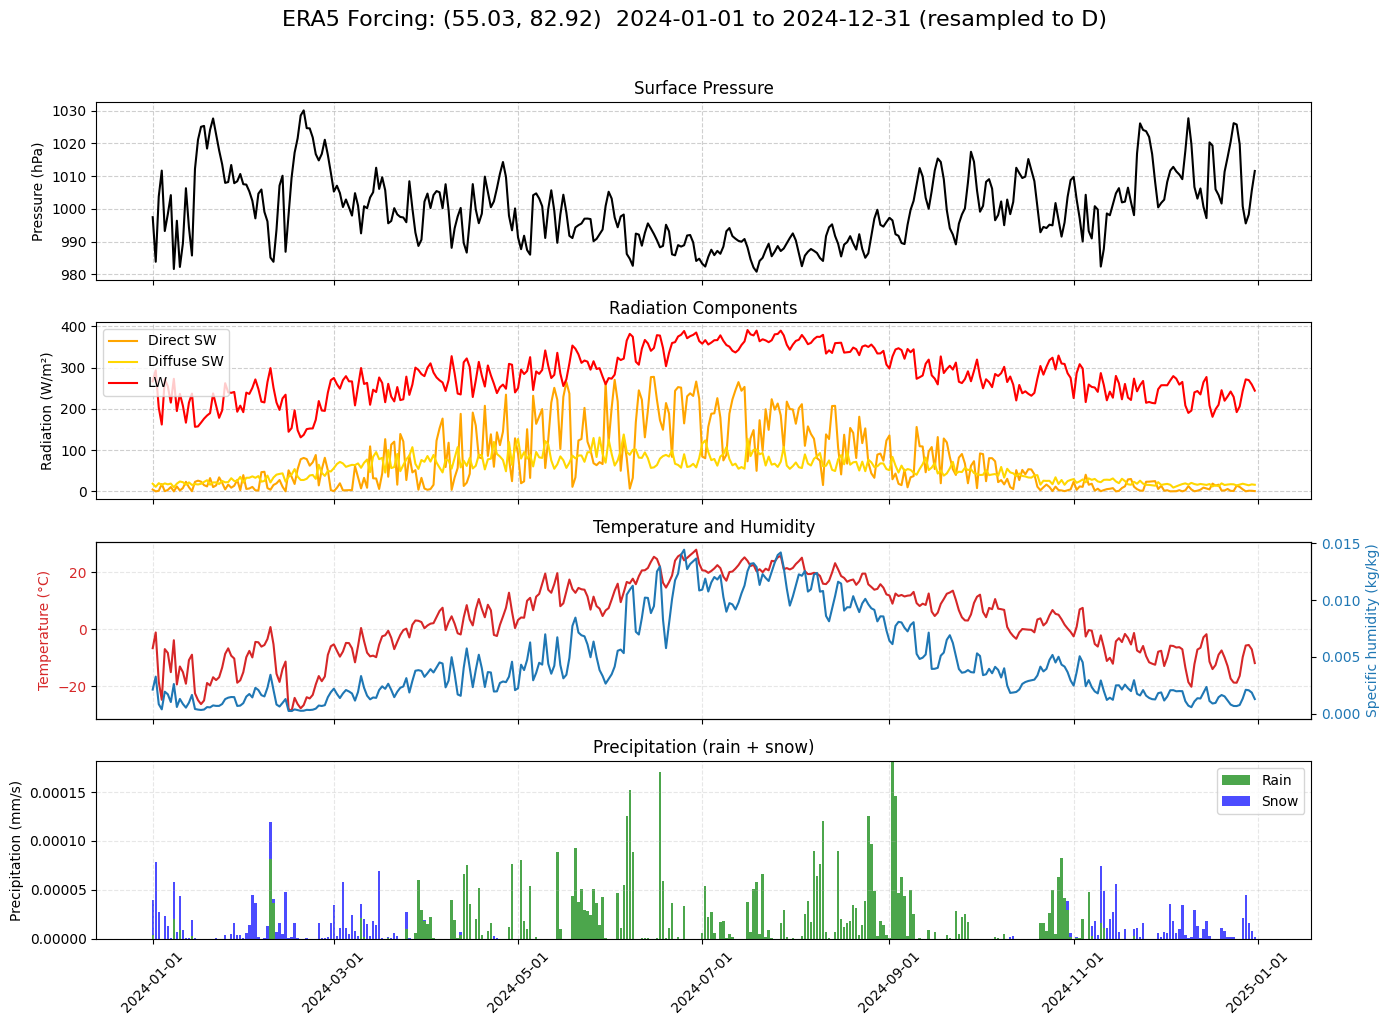

✅ Plot saved to Novosibirsk/era5_forcing_2024-01-01_2024-12-31.png


In [9]:
forcing_ERA5 = import_and_reload ('forcing_ERA5')
os.chdir(WORK_DIR)

forcing_params = dict(lat = 55.030204,
                      lon = 82.920430,
                      base_dir = 'Novosibirsk',
                      start_date = '2024-01-01',
                      end_date = '2024-12-31',
                      time = '1h')


forcing_ERA5.prepare_forcing (**forcing_params)

## Model compilation

In [10]:
run_utils = import_and_reload ('run_utils')

start_time = time.time()

# !make -C {MODEL_DIR} clean > {MODEL_DIR}/make_clean_output.txt 2>&1
# !make -C {MODEL_DIR} all > {MODEL_DIR}/make_all_output.txt 2>&1

for comand in ['clean', 'all']:
  run_utils.run_in_cell(exe_path='make',
                        args=['-C', MODEL_DIR, comand],
                        num_lines = 10,
                        log_file=f'{MODEL_DIR}/make_{comand}_output.txt')

new_files = [f for f in glob.glob(MODEL_DIR + '/*.*') if os.path.getmtime(f) >= start_time]

print('\nCompilation finished, new files created:\n' + '\n'.join('\t' + f for f in new_files))

exe_files = [f for f in new_files if f.endswith('.exe')]
if exe_files:
  if len (exe_files) == 1:
    EXE_PATH = exe_files[0]
    EXE_FILE = os.path.basename(EXE_PATH)
    print (f'✅ Compilation is successfull, executable is {EXE_PATH}')
  else:
    print ('❌ Something is wrong: there is more than one new executable file')
else:
    print ('❌ Something is wrong: there are not any new executable file')


gfortran   -funderscoring -O0 -g -Wall -c -fmessage-length=0 -fdefault-real-8 -ffpe-trap=invalid,zero -ffree-line-length-0 -Wno-tabs -Wno-unused -Wno-align-commons -I. -Isrc_teb -Jobj -I. -Isrc_teb  -c src_teb/init_surfconsphy.F -o obj/init_surfconsphy.o
gfortran   -funderscoring -O0 -g -Wall -c -fmessage-length=0 -fdefault-real-8 -ffpe-trap=invalid,zero -ffree-line-length-0 -Wno-tabs -Wno-unused -Wno-align-commons -I. -Isrc_teb -Jobj -I. -Isrc_teb  -c src_driver/add_forecast_to_date_surf.F90 -o obj/add_forecast_to_date_surf.o
gfortran   -funderscoring -O0 -g -Wall -c -fmessage-length=0 -fdefault-real-8 -ffpe-trap=invalid,zero -ffree-line-length-0 -Wno-tabs -Wno-unused -Wno-align-commons -I. -Isrc_teb -Jobj -I. -Isrc_teb  -c src_teb/bld_occ_calendar.F90 -o obj/bld_occ_calendar.o
gfortran   -funderscoring -O0 -g -Wall -c -fmessage-length=0 -fdefault-real-8 -ffpe-trap=invalid,zero -ffree-line-length-0 -Wno-tabs -Wno-unused -Wno-align-commons -I. -Isrc_teb -Jobj -I. -Isrc_teb  -c src_teb/

## Model execution

In [11]:
forcing_dir = 'Novosibirsk'
shutil.copy (f'{WORK_DIR}/{forcing_dir}/namelist_forcing.nml',
             f'{MODEL_DIR}/namelist/')

'/content/TEB_work/TEB-Ru/namelist/namelist_forcing.nml'

In [12]:
with open(f'{MODEL_DIR}/namelist/namelist_forcing.nml', "r", encoding="utf-8") as file:
    content = file.read()
    print(content)

&tebforcing
    forc_step = 3600.0
    forcing_path = '/content/TEB_work/Novosibirsk/forcing/'
    hlev_teb = 10.0
    lat_teb = 55.030204
    lon_teb = 82.92043
    nsteps = 8784
    teb_day = 1
    teb_hour = 0.0
    teb_min = 0.0
    teb_month = 1
    teb_year = 2024
/



In [13]:
run_utils = import_and_reload ('run_utils')
run_utils.run_in_cell(exe_path='./TEB_offline.exe', log_file='log.txt', cwd = MODEL_DIR, num_lines=5)

 8749/ 8783
 8750/ 8783
 8751/ 8783
 8752/ 8783
 8753/ 8783
 8754/ 8783
 8755/ 8783
 8756/ 8783
 8757/ 8783
 8758/ 8783
 8759/ 8783
 8760/ 8783
 8761/ 8783
 8762/ 8783
 8763/ 8783
 8764/ 8783
 8765/ 8783
 8766/ 8783
 8767/ 8783
 8768/ 8783
 8769/ 8783
 8770/ 8783
 8771/ 8783
 8772/ 8783
 8773/ 8783
 8774/ 8783
 8775/ 8783
 8776/ 8783
 8777/ 8783
 8778/ 8783
 8779/ 8783
 8780/ 8783
 8781/ 8783
 8782/ 8783
 8783/ 8783
  
     --------------------------
     |  DRIVER ENDS CORRECTLY |
     --------------------------
  
✅ Process finished (return code 0). Full log saved to 'log.txt'.


0